# Deep Learning Frameworks: TensorFlow, PyTorch, and Keras Fundamentals

This notebook explores the fundamental concepts and basic operations within three popular deep learning frameworks: TensorFlow, PyTorch, and Keras. It covers tensor creation, manipulation, variable handling, mathematical operations, gradient computation, and an end-to-end example for a linear classifier in each framework.

#### First steps with TensorFlow

---

##### Tensors and variables in TensorFlow

This section introduces how to create and manipulate tensors, which are the fundamental data structures in TensorFlow. It also covers the concept of `tf.Variable` for mutable tensors, crucial for trainable parameters in neural networks.

###### Constant tensors

Constant tensors are immutable tensors whose values cannot be changed after creation. They are used for fixed data in computations.

In [1]:
import tensorflow as tf
tf.ones(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

Let's create some constant tensors using `tf.ones`, `tf.zeros`, and `tf.constant`.

In [2]:
tf.zeros(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [3]:
tf.constant([1, 2, 3], dtype="float32")

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>

###### Random tensors

Random tensors are often used for initializing weights in neural networks or for generating random data. TensorFlow provides functions to create tensors with values sampled from various distributions.

In [4]:
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[-0.33892533]
 [-0.00335873]
 [-0.30281973]], shape=(3, 1), dtype=float32)


Here, we generate random tensors from a normal distribution (`tf.random.normal`) and a uniform distribution (`tf.random.uniform`).

In [5]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[0.44522047]
 [0.09668326]
 [0.19822192]], shape=(3, 1), dtype=float32)


###### Tensor assignment and the Variable class

Unlike standard tensors, `tf.Variable` objects are mutable and can be updated, making them suitable for model parameters like weights and biases. This section demonstrates how to assign new values to a `tf.Variable`.

In [6]:
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 0] = 0.0

First, a numpy array is used to demonstrate how standard arrays can be assigned values. Then, a `tf.Variable` is created and its values are modified using `assign()` and `assign_add()`.

In [7]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 0.3562244],
       [ 1.4835601],
       [-1.2304101]], dtype=float32)>


In [8]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [9]:
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [10]:
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

##### Tensor operations: Doing math in TensorFlow

TensorFlow provides a rich set of mathematical operations that can be performed on tensors, similar to NumPy. This section illustrates some common tensor operations.

In [11]:
a = tf.ones((2, 2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a, b)
f = tf.concat((a, b), axis=0)

Examples include element-wise operations like `tf.square` and `tf.sqrt`, matrix multiplication `tf.matmul`, and tensor concatenation `tf.concat`. A simple `dense` function is also defined to show how these operations can be combined.

In [12]:
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

##### Gradients in TensorFlow: A second look at the GradientTape API

The `tf.GradientTape` API is central to automatic differentiation in TensorFlow, enabling the computation of gradients for optimization algorithms like gradient descent.

In [13]:
input_var = tf.Variable(initial_value=3.0)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)

This code demonstrates how to use `tf.GradientTape` to compute gradients of a function with respect to a `tf.Variable` and a `tf.constant` (by explicitly watching it). It also shows computing higher-order gradients.

In [14]:
input_const = tf.constant(3.0)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)

In [15]:
time = tf.Variable(0.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2
    speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)

##### Making TensorFlow functions fast using compilation

TensorFlow allows compiling Python functions into high-performance TensorFlow graphs using `tf.function` and `jit_compile` for significant speedups, especially in training loops.

In [16]:
@tf.function
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

Here, the `dense` function previously defined is decorated with `@tf.function` and `@tf.function(jit_compile=True)` to showcase compilation options.

In [17]:
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

#### An end-to-end example: A linear classifier in pure TensorFlow

This section presents a complete example of building and training a simple linear classifier using pure TensorFlow components, demonstrating data generation, model definition, loss calculation, and optimization.

In [18]:
import numpy as np

num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

We start by generating synthetic 2D data for two classes using `numpy.random.multivariate_normal`.

In [19]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [20]:
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

The generated data is then combined into `inputs` and corresponding `targets` (0s and 1s) for the binary classification task.

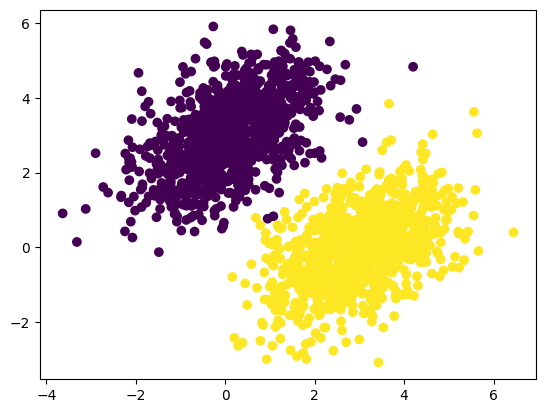

In [21]:
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

A scatter plot visualizes the two classes of synthetic data, where colors represent the target labels.

In [22]:
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

The linear model's weights (`W`) and bias (`b`) are initialized as `tf.Variable` objects, allowing them to be updated during training.

In [23]:
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

The `model` function defines the linear transformation: `inputs * W + b`.

In [24]:
def mean_squared_error(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

The `mean_squared_error` function calculates the loss between the model's predictions and the true targets.

In [25]:
learning_rate = 0.1

@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

The `training_step` function encapsulates the forward pass, loss calculation, gradient computation using `tf.GradientTape`, and weight updates (gradient descent). It's compiled with `jit_compile=True` for performance.

In [26]:
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 2.6929
Loss at step 1: 0.2888
Loss at step 2: 0.1331
Loss at step 3: 0.1050
Loss at step 4: 0.0954
Loss at step 5: 0.0889
Loss at step 6: 0.0832
Loss at step 7: 0.0782
Loss at step 8: 0.0735
Loss at step 9: 0.0693
Loss at step 10: 0.0655
Loss at step 11: 0.0620
Loss at step 12: 0.0588
Loss at step 13: 0.0558
Loss at step 14: 0.0532
Loss at step 15: 0.0508
Loss at step 16: 0.0486
Loss at step 17: 0.0465
Loss at step 18: 0.0447
Loss at step 19: 0.0430
Loss at step 20: 0.0415
Loss at step 21: 0.0401
Loss at step 22: 0.0388
Loss at step 23: 0.0377
Loss at step 24: 0.0366
Loss at step 25: 0.0356
Loss at step 26: 0.0348
Loss at step 27: 0.0340
Loss at step 28: 0.0332
Loss at step 29: 0.0326
Loss at step 30: 0.0319
Loss at step 31: 0.0314
Loss at step 32: 0.0309
Loss at step 33: 0.0304
Loss at step 34: 0.0300
Loss at step 35: 0.0296
Loss at step 36: 0.0293
Loss at step 37: 0.0289
Loss at step 38: 0.0287
Loss at step 39: 0.0284


The model is trained for 40 steps, with the loss printed at each step to monitor convergence.

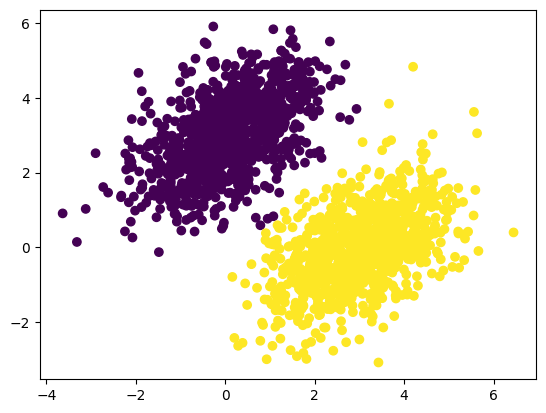

In [27]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

After training, the model's predictions are used to color the data points, showing how well the linear classifier separates the two classes. The image should look similar to the original data visualization.

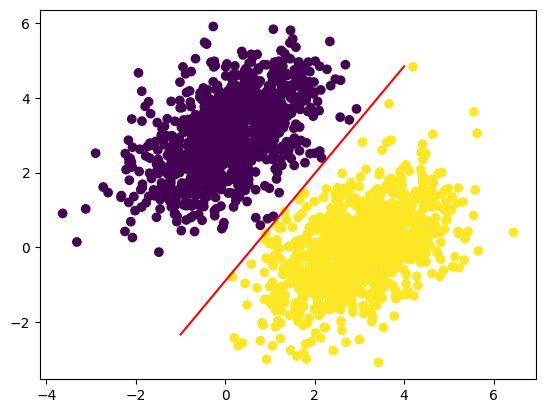

In [28]:
x = np.linspace(-1, 4, 100)
y = -W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

This plot further visualizes the decision boundary learned by the linear model, represented as a red line, superimposed on the data points.

### Introduction to PyTorch

---

#### First steps with PyTorch

This section introduces how to create and manipulate tensors, which are the fundamental data structures in PyTorch. It also covers the concept of `torch.nn.Parameter` for mutable tensors, crucial for trainable parameters in neural networks.

##### Tensors and parameters in PyTorch

This section delves into the core data structures in PyTorch: Tensors and Parameters. Tensors are multi-dimensional arrays, similar to NumPy arrays, but with GPU acceleration capabilities. Parameters are a special type of tensor designed to be learned during model training.

###### Constant tensors

Constant tensors are immutable tensors whose values cannot be changed after creation. They are used for fixed data in computations.

In [29]:
import torch
torch.ones(size=(2, 1))

tensor([[1.],
        [1.]])

Let's create some constant tensors using `torch.ones`, `torch.zeros`, and `torch.tensor`.

In [30]:
torch.zeros(size=(2, 1))

tensor([[0.],
        [0.]])

In [31]:
torch.tensor([1, 2, 3], dtype=torch.float32)

tensor([1., 2., 3.])

###### Random tensors

Random tensors are often used for initializing weights in neural networks or for generating random data. PyTorch provides functions to create tensors with values sampled from various distributions.

In [32]:
torch.normal(
mean=torch.zeros(size=(3, 1)),
std=torch.ones(size=(3, 1)))

tensor([[ 1.3764],
        [-2.1221],
        [ 0.6676]])

Here, we generate random tensors from a normal distribution (`torch.normal`) and a uniform distribution (`torch.rand`).

In [33]:
torch.rand(3, 1)

tensor([[0.7242],
        [0.7804],
        [0.8320]])

###### Tensor assignment and the Parameter class

Unlike standard tensors, `torch.nn.Parameter` objects are mutable and automatically registered as model parameters, making them suitable for model parameters like weights and biases. This section demonstrates how to assign new values to a PyTorch tensor and introduces `torch.nn.Parameter`.

In [34]:
x = torch.zeros(size=(2, 1))
x[0, 0] = 1.
x

tensor([[1.],
        [0.]])

First, a regular PyTorch tensor is created and modified. Then, a `torch.nn.Parameter` is created from a tensor.

In [35]:
x = torch.zeros(size=(2, 1))
p = torch.nn.parameter.Parameter(data=x)

##### Tensor operations: Doing math in PyTorch

PyTorch provides a rich set of mathematical operations that can be performed on tensors, similar to NumPy. This section illustrates some common tensor operations.

In [36]:
a = torch.ones((2, 2))
b = torch.square(a)
c = torch.sqrt(a)
d = b + c
e = torch.matmul(a, b)
f = torch.cat((a, b), dim=0)

Examples include element-wise operations like `torch.square` and `torch.sqrt`, matrix multiplication `torch.matmul`, and tensor concatenation `torch.cat`. A simple `dense` function is also defined to show how these operations can be combined.

In [37]:
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

##### Computing gradients with PyTorch

PyTorch's automatic differentiation engine (`autograd`) is crucial for training neural networks. It automatically computes gradients for all operations on tensors with `requires_grad=True`.

In [38]:
input_var = torch.tensor(3.0, requires_grad=True)
result = torch.square(input_var)
result.backward()
gradient = input_var.grad
gradient

tensor(6.)

This code demonstrates how to compute gradients of a function with respect to an input tensor. Note the importance of `input_var.grad = None` to clear previous gradients before computing new ones.

In [39]:
result = torch.square(input_var)
result.backward()
input_var.grad

tensor(12.)

In [40]:
input_var.grad = None

#### An end-to-end example: A linear classifier in pure PyTorch

This section presents a complete example of building and training a simple linear classifier using pure PyTorch components, demonstrating data generation, model definition, loss calculation, and optimization.

In [41]:
input_dim = 2
output_dim = 1

W = torch.rand(input_dim, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)

The linear model's weights (`W`) and bias (`b`) are initialized as tensors with `requires_grad=True`, allowing them to accumulate gradients during training.

In [42]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b

The `model` function defines the linear transformation: `inputs * W + b`.

In [43]:
def mean_squared_error(targets, predictions):
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

The `mean_squared_error` function calculates the loss between the model's predictions and the true targets.

In [44]:
learning_rate = 0.1

def training_step(inputs, targets, W, b):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    grad_loss_wrt_W, grad_loss_wrt_b = W.grad, b.grad
    with torch.no_grad():
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate
    W.grad = None
    b.grad = None
    return loss

The `training_step` function performs a forward pass, calculates the loss, computes gradients using `loss.backward()`, and updates the weights and bias. `torch.no_grad()` is used to prevent gradient tracking during parameter updates, and gradients are manually cleared.

##### Packaging state and computation with the Module class

The `torch.nn.Module` class provides a base for all neural network modules. It allows organizing layers and managing parameters, making it easier to build complex models. The `forward` method defines the computation performed at every call.

In [45]:
class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))

    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b

Here, a `LinearModel` class is defined inheriting from `torch.nn.Module`, encapsulating the weights `W` and bias `b` as `torch.nn.Parameter` objects.

In [46]:
model = LinearModel()

An instance of the `LinearModel` is created.

In [47]:
torch_inputs = torch.tensor(inputs)
output = model(torch_inputs)

The `inputs` data (converted to a PyTorch tensor) is passed through the `model` to get predictions.

In [48]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

PyTorch optimizers, such as `torch.optim.SGD`, handle the update of model parameters based on computed gradients, simplifying the training process.

In [49]:
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad()
    return loss

This revised `training_step` uses an optimizer (`optimizer.step()`) to update parameters and `model.zero_grad()` to clear gradients, making the training loop more concise.

##### Making PyTorch modules fast using compilation

PyTorch introduced `torch.compile` to optimize models and functions for faster execution by leveraging techniques like graph compilation and hardware-specific optimizations.

In [50]:
compiled_model = torch.compile(model)

Here, both the entire `model` and the `dense` function are compiled using `torch.compile` to illustrate its usage.

In [51]:
@torch.compile
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

### Introduction to Keras

---

#### First steps with Keras

Keras is a high-level API for building and training deep learning models, known for its user-friendliness and modularity. This section covers the fundamental building blocks of Keras, including `Layer` and `Model` classes.

#### Layers: The building blocks of deep learning

This section introduces `Layers`, the foundational components in Keras for defining neural network operations. It covers how to create custom layers and use built-in layers.

##### The base `Layer` class in Keras

The `Layer` class is the basic abstraction in Keras for defining computations that operate on tensors. It manages weights, biases, and the forward pass logic.

In [52]:
import keras

class SimpleDense(keras.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation

    def build(self, input_shape):
        batch_dim, input_dim = input_shape
        self.W = self.add_weight(
            shape=(input_dim, self.units), initializer="random_normal"
        )
        self.b = self.add_weight(shape=(self.units,), initializer="zeros")

    def call(self, inputs):
        y = keras.ops.matmul(inputs, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)
        return y

A custom `SimpleDense` layer is implemented, inheriting from `keras.Layer`, demonstrating how to define `__init__`, `build` (for weight creation), and `call` (for forward pass) methods.

In [53]:
my_dense = SimpleDense(units=32, activation=keras.ops.relu)
input_tensor = keras.ops.ones(shape=(2, 784))
output_tensor = my_dense(input_tensor)
print(output_tensor.shape)

(2, 32)


An instance of `SimpleDense` is created and called with an input tensor, demonstrating its functionality and output shape.

##### Automatic shape inference: Building layers on the fly

Keras layers can automatically infer input shapes, allowing for flexible model building.

In [54]:
from keras import layers

layer = layers.Dense(32, activation="relu")

A `keras.layers.Dense` layer is instantiated without specifying the input shape initially.

In [55]:
from keras import models
from keras import layers

model = models.Sequential(
    [
        layers.Dense(32, activation="relu"),
        layers.Dense(32),
    ]
)

Keras `models` are composed of layers. The `Sequential` model is a straightforward way to build models by stacking layers in a linear fashion.

In [56]:
model = keras.Sequential(
    [
        SimpleDense(32, activation="relu"),
        SimpleDense(64, activation="relu"),
        SimpleDense(32, activation="relu"),
        SimpleDense(10, activation="softmax"),
    ]
)

A `Sequential` model is built using multiple `SimpleDense` layers, showcasing how custom layers can be integrated into Keras models.

#### From layers to models

After defining the layers, the next step is to combine them into a `Model` object. Keras models provide functionalities for training, evaluation, and prediction.

#### The "compile" step: Configuring the learning process

The `compile` method configures the model for training by specifying the optimizer, loss function, and metrics. This step prepares the model for the learning process.

In [57]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer="rmsprop",
    loss="mean_squared_error",
    metrics=["accuracy"],
)

A simple `Sequential` model with a single Dense layer is compiled with `rmsprop` optimizer and `mean_squared_error` loss. This illustrates the basic compilation step.

In [58]:
model.compile(
    optimizer=keras.optimizers.RMSprop(),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

This cell shows how to specify the optimizer, loss, and metrics using their respective Keras objects instead of string names, providing more control and flexibility.

#### Picking a loss function

Choosing the appropriate loss function is critical for guiding the model during training. It quantifies the difference between predicted and actual values.

#### Understanding the fit method

The `fit` method is where the model is actually trained on the provided data. It iterates over the dataset for a specified number of `epochs` and `batch_size`.

In [59]:
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128,
)

Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9500 - loss: 4.1051  
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9485 - loss: 3.8727 
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9480 - loss: 3.6787 
Epoch 4/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - binary_accuracy: 0.9480 - loss: 3.4947 
Epoch 5/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9465 - loss: 3.3164 


The model is trained on the `inputs` and `targets` data for 5 epochs with a batch size of 128. The output shows the loss and accuracy progression during training.

In [60]:
history.history

{'binary_accuracy': [0.949999988079071,
  0.9484999775886536,
  0.9480000138282776,
  0.9480000138282776,
  0.9465000033378601],
 'loss': [4.105090141296387,
  3.8727028369903564,
  3.678678274154663,
  3.494662284851074,
  3.3164100646972656]}

The `history` object returned by `model.fit()` contains a record of training loss and metrics values at successive epochs.

#### Monitoring loss and metrics on validation data

To prevent overfitting and evaluate the model's generalization performance, it's essential to monitor its performance on a separate validation dataset. This helps in detecting when the model starts learning noise from the training data rather than the underlying patterns.

In [61]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
    loss=keras.losses.MeanSquaredError(),
    metrics=[keras.metrics.BinaryAccuracy()],
)

indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets),
)

Epoch 1/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9564 - loss: 0.4442 - val_binary_accuracy: 0.9900 - val_loss: 0.0578
Epoch 2/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9450 - loss: 0.0751 - val_binary_accuracy: 0.9817 - val_loss: 0.0445
Epoch 3/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9600 - loss: 0.0710 - val_binary_accuracy: 0.9683 - val_loss: 0.0574
Epoch 4/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9521 - loss: 0.0747 - val_binary_accuracy: 0.9733 - val_loss: 0.1099
Epoch 5/5
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.9607 - loss: 0.0737 - val_binary_accuracy: 0.5917 - val_loss: 0.1978


The data is shuffled and split into training and validation sets. The `model.fit()` method is then called with `validation_data` to monitor performance on the validation set during training.

#### Inference: Using a model after training

After training, the model can be used to make predictions on new, unseen data using the `predict` method.

In [62]:
predictions = model.predict(val_inputs, batch_size=128)
print(predictions[:10])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[[-0.18800583]
 [ 0.38531017]
 [ 0.05255723]
 [ 0.4275707 ]
 [ 0.4868831 ]
 [ 0.10753921]
 [ 0.10811743]
 [ 0.16998546]
 [ 0.5502543 ]
 [ 0.54707587]]


The trained model makes predictions on the `val_inputs`, and the first 10 predictions are printed. These predictions represent the model's output for the given inputs.